# Completing XGBoost Analysis
Assumption that appropriate separation and PCA has been completed.

## SETUP

In [1]:
import subprocess, sys, os, importlib, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgb_functions
import xgboost as xgb
importlib.reload(xgb_functions)

from scipy.stats import randint

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report 

In [2]:
def overall_xgb(results_dir, transformed_data_dir, dataset):
    # Initialize an empty list to store the results
    results = []
    
    files = [f for f in os.listdir(transformed_data_dir) if f.startswith('transformed')]

    for filename in files:
        x_train, x_test, y_train, y_test, y_pred = xgb_functions.perform_xgboost(transformed_data_dir, filename)

        # Perform Random Forest and get mse and r2
        mae, mse, rmse, r2, adjusted_r2 = xgb_functions.obtain_xgb_evaluations(x_train, y_test, y_pred)

        # Extract the energy range and cumulative variance ratio from the filename
        energy_range_match = re.search(r'\[([-+]?\d*\.\d+|\d+),([-+]?\d*\.\d+|\d+)\]', filename)
        cum_variance_match = re.search(r'var([\d\.]+)', filename)

        if energy_range_match and cum_variance_match:
            energy_range = f"{energy_range_match.group(1)},{energy_range_match.group(2)}"
            cum_variance = cum_variance_match.group(1).rstrip('.')

            # Append the results to the list as a dictionary
            results.append({
                'dataset': dataset.replace('transformed_data_', ''),
                'energy_range': energy_range,
                'cum_variance': cum_variance,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'R^2': r2,
                'Adjusted_R^2': adjusted_r2
            })

    # Convert the results list into a DataFrame
    results_df = pd.DataFrame(results)

    # Save results in overall results excel
    excel_name = os.path.join(results_dir, 'overall_results.xlsx')
    sheet_name = f'xgb_results_{dataset}'

    # Save to Excel (append if file already exists)
    if os.path.exists(excel_name):
        # If Excel file does not exists, create a new Excel file
        with pd.ExcelWriter(excel_name, mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
            results_df.to_excel(writer, sheet_name=sheet_name, index=False) 
    else:
        with pd.ExcelWriter(excel_name) as writer:
            results_df.to_excel(writer, sheet_name=sheet_name, index=False) 

    return results_df

In [3]:
# Create an empty DataFrame
overall_results = pd.DataFrame(columns=['dataset',
                                        'energy_range',
                                        'cum_variance',
                                        'MAE',
                                        'MSE',
                                        'RMSE',
                                        'R^2',
                                        'Adjusted_R^2'], dtype='float64')

overall_results

,dataset,energy_range,cum_variance,MAE,MSE,RMSE,R^2,Adjusted_R^2


In [4]:
base_dir = os.path.dirname(os.getcwd())
results_dir = os.path.join(base_dir, 'RESULTS')

transformed_data_dirs = ['transformed_data_DOSCAR_files']
# transformed_data_dirs = [f for f in os.listdir(results_dir) if f.startswith('transformed_data')]

for dir in transformed_data_dirs:
    print(f"Processing directory is {dir}")
    dir_path = os.path.join(results_dir, dir)
    cur_results = overall_xgb(results_dir, dir_path, dir)
    overall_results = pd.concat([overall_results, cur_results], ignore_index=True).drop_duplicates()

overall_results

Processing directory is transformed_data_DOSCAR_files


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\.venv\Lib\site-packages\openpyxl\workbook\child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


,dataset,energy_range,cum_variance,MAE,MSE,RMSE,R^2,Adjusted_R^2
0,DOSCAR_files,"-1.46,3.27",0.80,0.208060,0.096792,0.311113,-1.335591,-1.422095
1,DOSCAR_files,"-1.46,3.27",0.90,0.160470,0.044957,0.212031,-0.084818,-0.191173
2,DOSCAR_files,"-10.00,10.00",0.80,0.128109,0.029225,0.170954,0.294788,-0.067348
3,DOSCAR_files,"-10.00,10.00",0.90,0.127243,0.027549,0.165978,0.335245,-0.861313
4,DOSCAR_files,"-5.00,5.00",0.80,0.149749,0.041156,0.202870,0.006892,-0.293350
5,DOSCAR_files,"-5.00,5.00",0.90,0.163020,0.046079,0.214661,-0.111899,-0.886859


In [5]:
def plot_xgb(transformed_data_dir, energy_range, variance):
    filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

    x_train, x_test, y_train, y_test, y_pred = xgb_functions.perform_xgboost(transformed_data_dir, filename)
    xgb_functions.plot_xgb_results(y_test, y_pred, energy_range, variance)

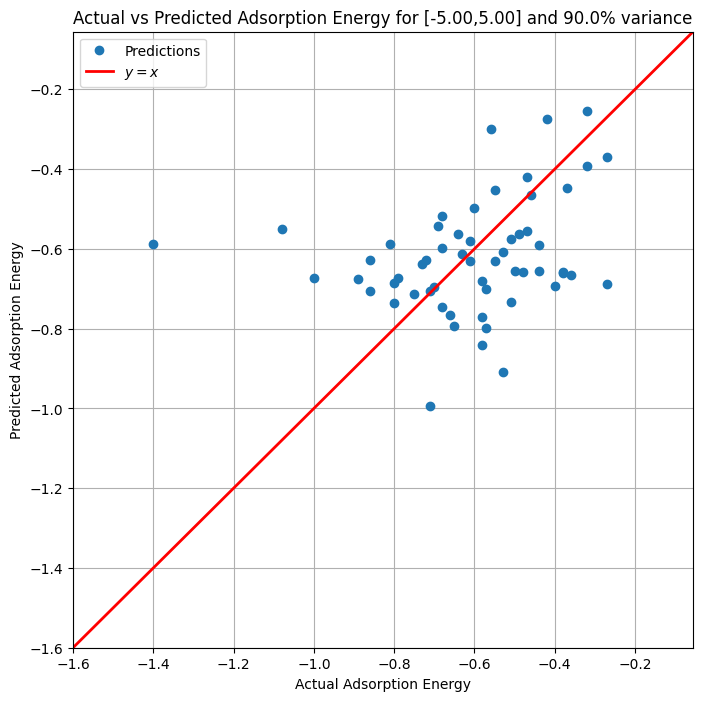

In [6]:
transformed_data_dir = os.path.join(results_dir,'transformed_data_DOSCAR_files')

### FOR -5.00, 5.00 AND 90% VARIANCE

energy_range = '[-5.00,5.00]'
variance = 0.90

plot_xgb(transformed_data_dir, energy_range, variance)

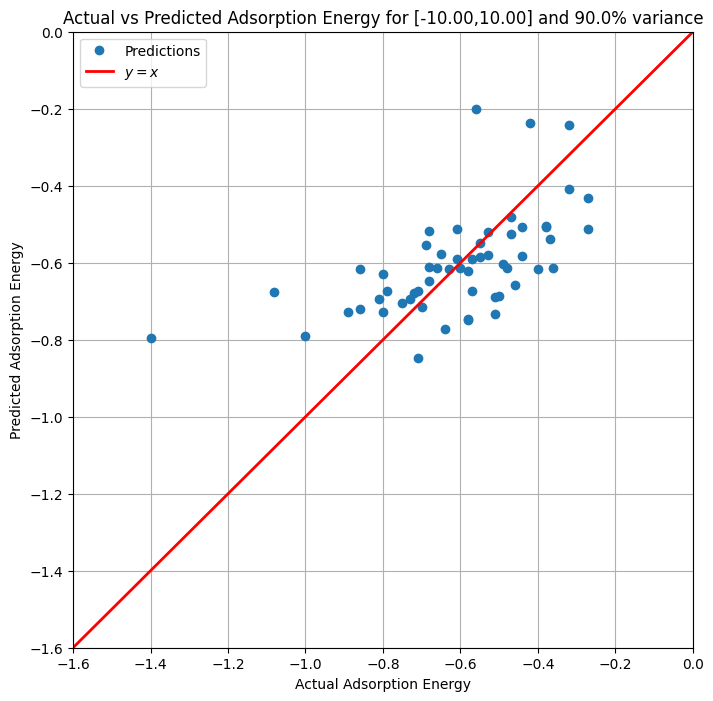

In [7]:
### FOR -10.00, 10.00 AND 90% VARIANCE

energy_range = '[-10.00,10.00]'
variance = 0.90

plot_xgb(transformed_data_dir, energy_range, variance)

# Optimising hyper parameters and cross-validation

In [8]:
def perform_randomsearch(transformed_data_dir, filename, param_grid):
    filepath = os.path.join(transformed_data_dir, filename)

    # Load and process the data
    pca_data = xgb_functions.load_pca_transformed_data(filepath)
    merged_data = xgb_functions.adsorption_energy_for_dataset(pca_data)

    # Prepare the data
    x = merged_data.drop(columns=['Molecule','Ads.'])
    y = merged_data['Ads.']

    # Split the data
    x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

    # Perform Randomized Search with 5-fold Cross-Validation
    random_search = RandomizedSearchCV(
        xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
        param_distributions=param_grid,
        scoring="neg_mean_absolute_error",
        n_iter=20,  # Number of random combinations to test
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    # Fit the model
    random_search.fit(x_train, y_train)

    # Evaluate on test set
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(x_test)

    return random_search, x_train, x_test, y_train, y_test, y_pred

In [9]:
# Define hyperparameter distribution
param_grid = {
    "n_estimators": np.arange(100, 1000, 100),
    "learning_rate": np.linspace(0.01, 0.2, 10),
    "max_depth": np.arange(3, 10, 2),
    "subsample": np.linspace(0.5, 1.0, 5),
    "colsample_bytree": np.linspace(0.5, 1.0, 5)
}

In [10]:
### FOR -5.00, 5.00 AND 90% VARIANCE

transformed_data_dir = os.path.join(results_dir,'transformed_data_DOSCAR_files')

energy_range = '[-5.00,5.00]'
variance = 0.90

filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

random_search, x_train, x_test, y_train, y_test, y_pred_grid = perform_randomsearch(transformed_data_dir, filename, param_grid)

# Best Parameters
best_params = random_search.best_params_

# Convert the dictionary of best parameters to a DataFrame and transpose it
best_params_df = pd.DataFrame(list(best_params.items()), columns=['Parameter', 'Value'])

print(f"Best Parameters (Random Search): ")
best_params_df

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters (Random Search): 


,Parameter,Value
0,subsample,0.50
1,n_estimators,600.00
2,max_depth,5.00
3,learning_rate,0.01
4,colsample_bytree,1.00


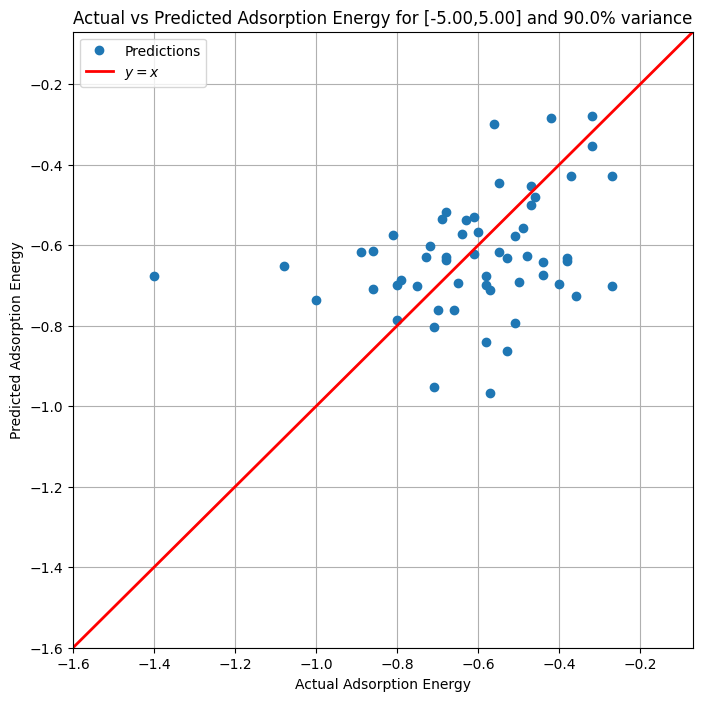

In [11]:
xgb_functions.plot_xgb_results(y_test, y_pred_grid, energy_range, variance)

In [12]:
### FOR -10.00, 10.00 AND 90% VARIANCE

transformed_data_dir = os.path.join(results_dir,'transformed_data_DOSCAR_files')

energy_range = '[-10.00,10.00]'
variance = 0.90

filename = f'transformed_data_{energy_range}_var{variance:.2f}.txt'

random_search, x_train, x_test, y_train, y_test, y_pred_grid = perform_randomsearch(transformed_data_dir, filename, param_grid)

# Best Parameters
best_params = random_search.best_params_

# Convert the dictionary of best parameters to a DataFrame and transpose it
best_params_df = pd.DataFrame(list(best_params.items()), columns=['Parameter', 'Value'])

print(f"Best Parameters (Random Search): ")
best_params_df

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters (Random Search): 


,Parameter,Value
0,subsample,0.50
1,n_estimators,600.00
2,max_depth,5.00
3,learning_rate,0.01
4,colsample_bytree,1.00


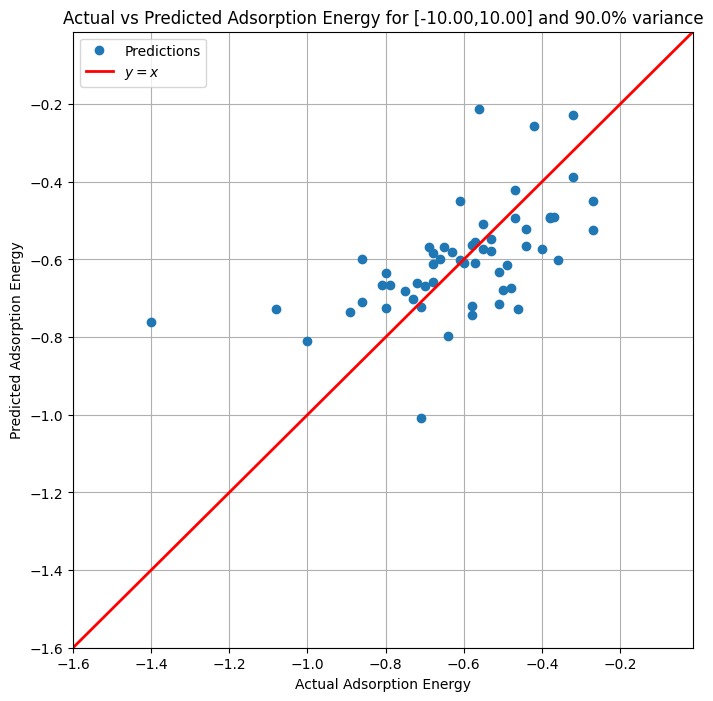

In [13]:
xgb_functions.plot_xgb_results(y_test, y_pred_grid, energy_range, variance) 